Importing Libraries

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from arch import arch_model

import sys
import os

sys.path.append(os.path.abspath("../src"))

In [36]:
import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import scipy
import statsmodels
import arch

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)
print("arch:", arch.__version__)

numpy: 1.26.4
pandas: 2.2.3
matplotlib: 3.10.0
seaborn: 0.13.2
scipy: 1.12.0
statsmodels: 0.14.6
arch: 8.0.0


## Data Preparation and Return Construction

In this section, we construct a clean dataset of weekly asset returns across multiple asset classes, including cryptocurrencies, equities, and bonds.

### 1. Data Loading and Cleaning

We begin by loading the merged dataset and preparing it:

- The dataset is indexed by date and converted to a `DatetimeIndex`
- Missing values are removed to ensure consistency across assets
- Ethereum (ETH) is used as the base reference due to its shortest available history, ensuring alignment across all assets

### 2. Resampling to Weekly Frequency

To reduce noise and standardize the time horizon, we resample all price series to weekly frequency (Friday close).

The assets considered are:

- BTC (Bitcoin)  
- ETH (Ethereum)  
- SP500 (S&P 500 Index)  
- VTI (Total US Equity Market ETF)  
- AGG (US Aggregate Bond ETF)  
- TLT (Long-Term Treasury Bond ETF)  

### 3. Log Returns Computation

We compute weekly log returns. Log returns are used because they are time-additive, they exhibit better statistical properties than simple returns, and they are widely used in financial econometrics and portfolio modelling

### 4. Summary Statistics

We inspect the dataset by computing:

- Number of observations  
- Date range  
- Missing values  
- Descriptive statistics of returns  

array([<Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>,
       <Axes: xlabel='date'>, <Axes: xlabel='date'>], dtype=object)

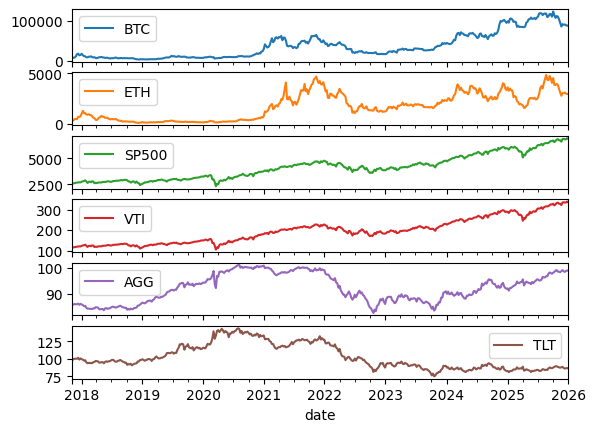

In [37]:
# initialize dataframe with eth has it has the shortest date range
df = pd.read_csv("../data/merged_data_v2.csv", index_col='date')
df.dropna(inplace=True)
df.index= pd.to_datetime(df.index, format = '%Y-%m-%d')
weekly_df = df[["btc_adj_close", "eth_adj_close", "sp500_adj_close", "vti_adj_close", "agg_adj_close", "tlt_adj_close"]].resample("W-FRI").last().dropna()
weekly_df.columns = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"]
weekly_df.plot(subplots=True)

In [38]:
price_assets = ["BTC", "ETH", "SP500", "VTI", "AGG", "TLT"] # treasury yield is in rates, will be treated differently
weekly_logret = 100*np.log(weekly_df[price_assets] / weekly_df[price_assets].shift(1)).dropna()
weekly_logret.head()

,BTC,ETH,SP500,VTI,AGG,TLT
date,,,,,,
2017-11-19,15.257283,10.503171,-0.133689,0.075442,0.293155,1.828457
2017-11-26,6.827321,35.680639,0.909815,1.102159,0.200999,0.323876
2017-12-03,28.501417,-1.778366,1.517771,1.450900,-0.126307,0.006617
2017-12-10,41.188305,-2.278298,0.350606,0.300862,0.027492,0.110589
2017-12-17,6.639677,40.605187,0.912664,0.780926,0.256062,1.301817


In [39]:
print(f"Weekly obs : {len(weekly_logret)}")
print(f"Date range : {weekly_logret.index[0].date()} → {weekly_logret.index[-1].date()}")
print(f"\nMissing values:\n{weekly_logret.isnull().sum()}")
print(f"\nDescriptive stats:\n{weekly_logret.describe().round(4)}")
# as expected, volatility of crypto>stocks>bonds

Weekly obs : 425
Date range : 2017-11-19 → 2026-01-04

Missing values:
BTC      0
ETH      0
SP500    0
VTI      0
AGG      0
TLT      0
dtype: int64

Descriptive stats:
            BTC       ETH     SP500       VTI       AGG       TLT
count  425.0000  425.0000  425.0000  425.0000  425.0000  425.0000
mean     0.6075    0.5398    0.2294    0.2492    0.0335   -0.0301
std      9.3644   12.0246    2.5695    2.6347    0.7719    2.0308
min    -49.4484  -60.3355  -16.2279  -16.5557   -5.2249   -8.0053
25%     -3.5334   -5.6784   -1.0172   -1.0605   -0.3461   -1.1682
50%      0.3681    0.2524    0.4872    0.5327    0.0567    0.0789
75%      5.0951    7.0441    1.6065    1.6849    0.4084    1.1863
max     41.1883   50.6363   11.4237   12.1791    4.9123    7.2668


## GARCH Volatility Modelling

We estimate and compare GARCH-family models (GARCH, GJR-GARCH, EGARCH) with different error distributions (Skewed-t, GED) for each asset. The optimal model is selected based on BIC, and diagnostics are used to validate model adequacy. The resulting conditional volatility series is stored for subsequent spillover analysis.

### 1. Model Selection Summary

For each asset, the model with the lowest BIC is selected:

- **BTC**: EGARCH(1,1)-GED  
- **ETH**: EGARCH(1,1)-GED  
- **SP500**: EGARCH(1,1)-Skewed-t  
- **VTI**: EGARCH(1,1)-Skewed-t  
- **AGG**: GARCH(1,1)-GED  
- **TLT**: GARCH(1,1)-Skewed-t  

### 2. Volatility Dynamics

Key findings across assets:

- **Cryptocurrencies (BTC, ETH)**  
  - Extremely high persistence (β ≈ 0.99)  
  - Near-IGARCH behaviour → shocks are highly persistent  
  - Heavy tails remain even under GED

- **Equities (SP500, VTI)**  
  - Strong asymmetry (negative skewness)  
  - High volatility clustering but lower persistence than crypto  
  - EGARCH-Skewt best captures leverage effects

- **Bonds (AGG, TLT)**  
  - Lower volatility and simpler dynamics  
  - GARCH or EGARCH sufficient  
  - Much lower persistence compared to crypto

### 3. Diagnostic Checks

Across all assets:

- Ljung-Box tests: No significant autocorrelation in residuals or squared residuals  
- ARCH LM tests: No remaining ARCH effects, hence models adequately capture volatility clustering  
- Stationarity: All models are stationary (though crypto is near-IGARCH)  

### 4. Distributional Features

- All assets exhibit fat tails (excess kurtosis > 0 in most cases)  
- Equities show strong negative skewness
- GED reduces kurtosis but does not fully eliminate tail risk  
- Skewed-t generally performs best for equities and bonds

### 5. Key Interpretation

- Volatility persistence is highest in crypto, moderate in equities, and lowest in bonds
- EGARCH models capture leverage effects effectively in equity markets
- Heavy tails remain a structural feature across all asset classes
- Risk dynamics are strongly asset-dependent, justifying heterogeneous volatility models

In [40]:
from models.garch_functions import fit_all_garch, plot_garch_diagnostics, diagnostics_summary_table

In [41]:
garch_results = fit_all_garch(weekly_logret, model_type="auto")
plot_garch_diagnostics(garch_results)
diag_table = diagnostics_summary_table(garch_results)
cond_vol_df = pd.DataFrame({
    asset: garch_results[asset]["cond_vol"]
    for asset in garch_results
}).dropna()


GARCH fit: BTC

  --------------------------------------------------
  AR(1) mean detected (LB p=0.0843) -- using AR(1) mean equation

  Model competition [primary=skewt, mean=AR]:
  Model            Dist            AIC        BIC     Status
  --------------------------------------------------------
  GARCH            skewt       3019.33    3047.68         ok
  GJR              skewt       3013.32    3045.72         ok
  EGARCH           skewt            --         --   no convergence -> retrying with GED
  EGARCH           ged         2996.36    3024.71 GED fallback

  -> BIC selects: EGARCH-GED  (BIC=3024.71)
  EGARCH |beta|=0.9966  ->  stationary  |  near-IGARCH -- shocks near-permanent (half-life ~205 weeks)

  Post-fit [EGARCH-GED]:
  Ljung-Box resid   p@10=0.7343  p@20=0.6759
  Ljung-Box resid^2 p@10=0.3206  p@20=0.2469
  ARCH LM [std residuals -- post EGARCH]  LM=12.3459  p=0.4183  F=1.0271  p=0.4226  ->  no ARCH effects

  Normality / tail check [BTC]
  Obs                    

  EGARCH           skewt        833.02     861.38         ok

  -> BIC selects: GARCH-SKEWT  (BIC=859.11)
  GARCH alpha+beta=0.9768  ->  stationary  |  highly persistent (half-life ~30 weeks)

  Post-fit [GARCH-SKEWT]:
  Ljung-Box resid   p@10=0.8813  p@20=0.7958
  Ljung-Box resid^2 p@10=0.6879  p@20=0.8854
  ARCH LM [std residuals -- post GARCH]  LM=8.0786  p=0.7790  F=0.6650  p=0.7851  ->  no ARCH effects

  Normality / tail check [AGG]
  Obs                             : 425
  Skewness                        : -0.4945  (ok)
  Excess kurtosis                 : 2.1381  (fat tails remain)
  Jarque-Bera                     : stat=98.2780  p=0.0000  [informational only (skewt is non-normal by design)]
  KS vs normal (ref only)         : stat=0.0463  p=0.3128  [not meaningful for skewt]
  KS vs t: nu=None -- cannot run (df <= 2)
  [i] Excess kurtosis=2.14 -- mild fat tails remain after skewt -- GED refit will be attempted

  -> Refitting GARCH with GED (distribution test only) ...

  Post

In [42]:
diag_table

,Model,alpha,gamma,beta,Persistence,Metric,Stationary,Interpretation,Skewness,Excess Kurt,JB p-val,ARCH post p,AIC,BIC
Asset,,,,,,,,,,,,,,
BTC,EGARCH-GED,-0.0502,0.0483,0.9966,0.9966,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,0.1068,3.0259,0.0000,0.4183,2996.36,3024.71
ETH,EGARCH-GED,-0.0603,0.0345,0.9915,0.9915,|beta|,OK,near-IGARCH -- shocks near-permanent (half-lif...,-0.3219,1.8131,0.0000,0.5914,3253.62,3277.93
SP500,EGARCH-SKEWT,0.2013,-0.2571,0.9075,0.9075,|beta|,OK,highly persistent (half-life ~7 weeks),-1.2768,4.7203,0.0000,0.9459,1808.30,1840.70
VTI,EGARCH-SKEWT,0.2264,-0.2451,0.9119,0.9119,|beta|,OK,highly persistent (half-life ~8 weeks),-1.2656,4.7425,0.0000,0.9517,1831.78,1864.17
AGG,GARCH-GED,0.2660,--,0.7070,0.9768,alpha+beta,OK,highly persistent (half-life ~30 weeks),-0.4712,2.0392,0.0000,0.8295,839.51,859.77
TLT,GARCH-SKEWT,0.1071,--,0.8416,0.9488,alpha+beta,OK,highly persistent (half-life ~13 weeks),-0.1401,0.4928,0.0585,0.3219,1769.78,1798.13


In [43]:
import pickle

with open("../output/models/garch_results.pkl", "wb") as f:
    pickle.dump(cond_vol_df, f)

## Bubble Detection (GSADF) and Dummy Construction

We use GSADF test results to identify speculative bubble periods in BTC and ETH.

### 1. Bubble Extraction
Bubble detection procedure is run via GSADF tests. 

### 2. Dummy Construction
We construct time-aligned binary indicators:

- 1 during detected bubble periods  
- 0 otherwise  

The dummies are aligned with the conditional volatility index.

### 3. Output
The final `bubble_dummy` dataframe provides asset-specific bubble regimes for BTC and ETH, enabling integration with volatility and portfolio models.

### 4. Storage
The resulting dataset is saved as a pickle file for downstream analysis.


  BTC
  Weekly obs=426   r0=42 weeks
  GSADF... 2.5349


    CV 90%: 1.9534 <--
    CV 95%: 2.1710 <--
    CV 99%: 2.4114 <--
  BSADF sequence... 

done


  Bubble periods (95% CV, min 5 weeks):
    2021-01-03  →  2021-05-16  (20 wks)
    2024-03-03  →  2024-03-31  (5 wks)

  ETH
  Weekly obs=426   r0=42 weeks
  GSADF... 

1.8738


    CV 90%: 1.9539
    CV 95%: 2.1229
    CV 99%: 2.6327
  BSADF sequence... 

done


  Bubble periods (95% CV, min 5 weeks):
    2021-01-10  →  2021-05-16  (19 wks)

Plot saved → gsadf_bubble_detection.png

  GSADF TEST SUMMARY
Asset       GSADF     CV90     CV95     CV99  Sig
------------------------------------------------------------
BTC         2.535    1.953    2.171    2.411   ***
ETH         1.874    1.954    2.123    2.633   n.s.

*** p<0.01  ** p<0.05  * p<0.10  n.s. not significant


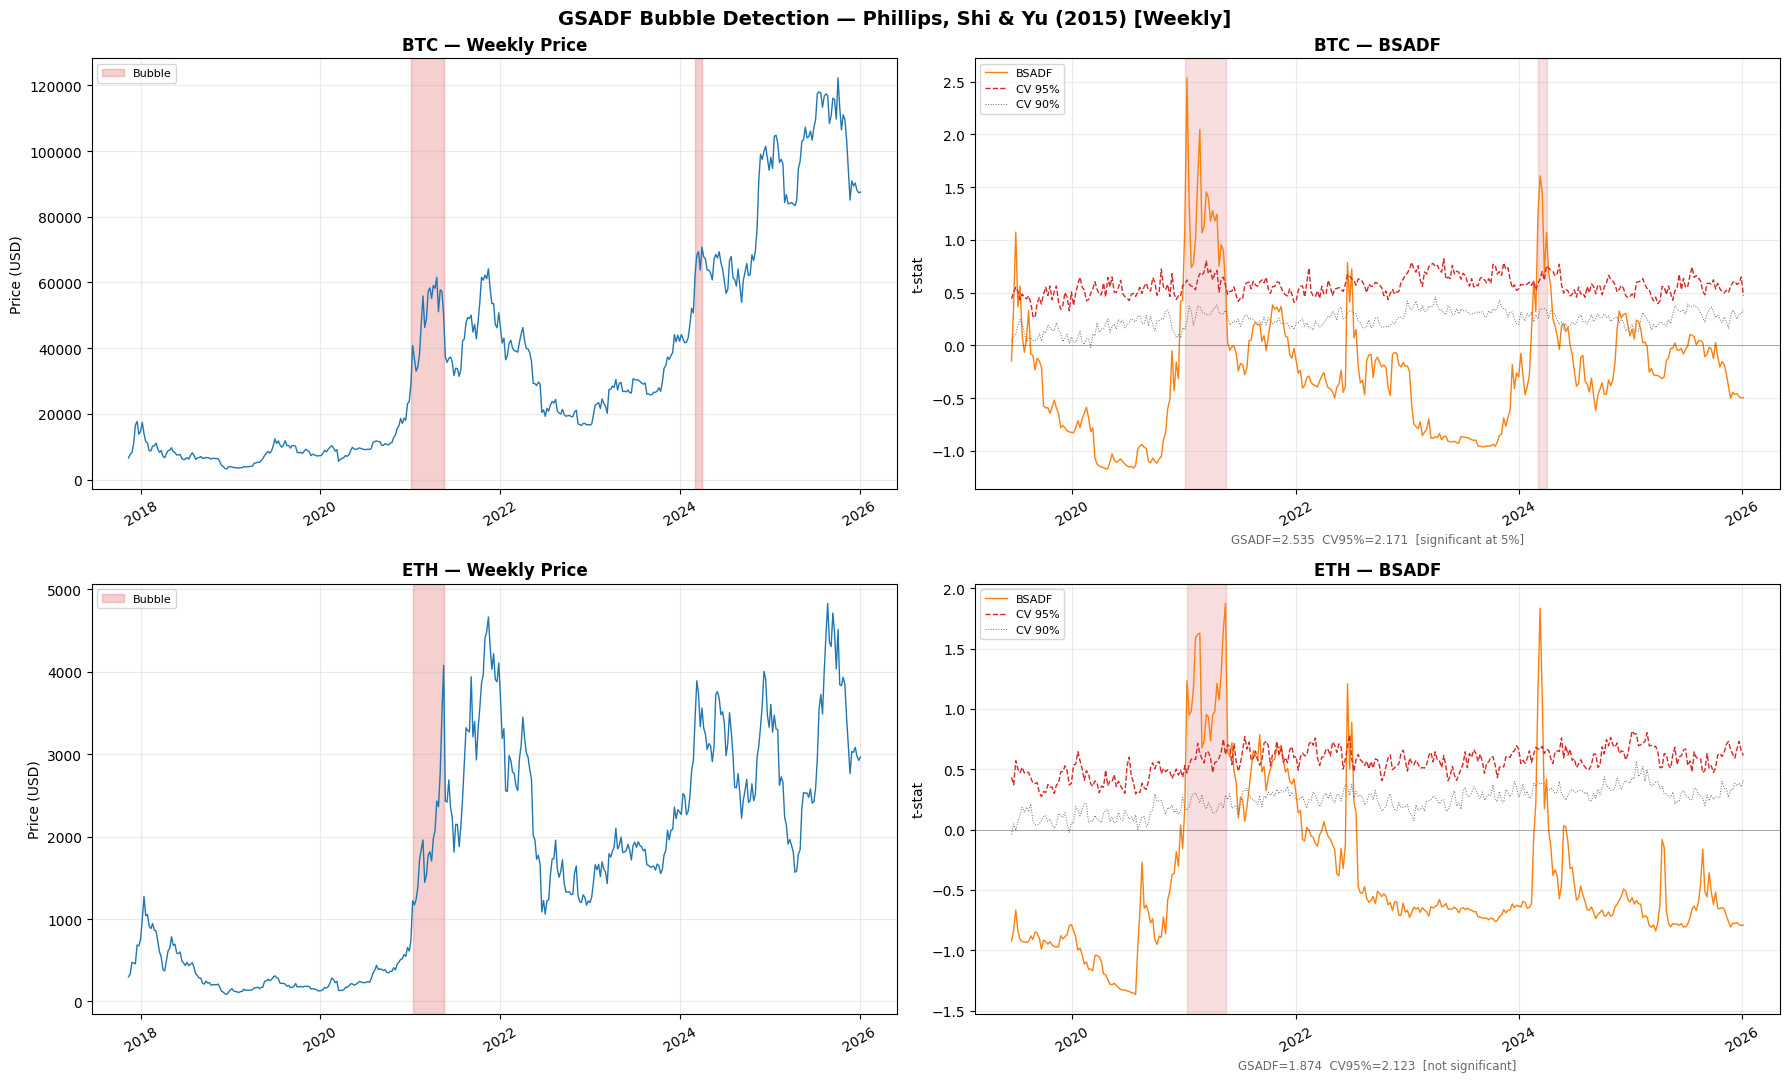

In [28]:
%run ../src/tests/GSADF_and_BSADF_tests.py

In [29]:
with open("../output/models/gsadf_results.pkl", "rb") as f:
    results = pickle.load(f)

In [30]:
bubble_rows = []

for asset, res in results.items():
    for start, end in res["bubbles"]:
        bubble_rows.append({
            "asset": asset,
            "start_date": pd.to_datetime(start),
            "end_date": pd.to_datetime(end)
        })

bubble_df = pd.DataFrame(bubble_rows)
dates = cond_vol_df.index
bubble_dummy = pd.DataFrame(0, index=dates, columns=["BTC", "ETH"])

for _, row in bubble_df.iterrows():
    mask = (bubble_dummy.index >= row["start_date"]) & (bubble_dummy.index <= row["end_date"])
    bubble_dummy.loc[mask, row["asset"]] = 1

bubble_dummy

,BTC,ETH
date,,
2017-11-26,0,0
2017-12-03,0,0
2017-12-10,0,0
2017-12-17,0,0
2017-12-24,0,0
...,...,...
2025-12-07,0,0
2025-12-14,0,0
2025-12-21,0,0


In [31]:
with open("../output/models/bubble_dummy.pkl", "wb") as f:
    pickle.dump(bubble_dummy, f)

In [32]:
def plot_conditional_volatility(garch_results: dict,
                                 bubble_indicators: pd.DataFrame,
                                 save_path: str = "../output/figures/conditional_volatility.png"):
    """Conditional volatility for all assets with bubble episode shading.
    
    Args:
        garch_results: Dict with asset keys containing 'cond_vol', 'model_type', 'dist'
        bubble_indicators: DataFrame with dates as index, assets as columns, 
                          binary values (1=bubble, 0=no bubble)
    """
    assets = list(garch_results.keys())
    fig, axes = plt.subplots(len(assets), 1,
                             figsize=(16, 3 * len(assets)), sharex=True)
    if len(assets) == 1:
        axes = [axes]
    
    for ax, asset in zip(axes, assets):
        cv   = garch_results[asset]["cond_vol"]
        dist = garch_results[asset].get("dist", "skewt")
        mod  = garch_results[asset]["model_type"]
        
        ax.fill_between(cv.index, cv.values, alpha=0.6,
                        color="steelblue", label=f"{asset} sigma_t")
        ax.set_ylabel("Cond. vol (%)")
        ax.set_title(f"{asset} -- {mod}(1,1)-{dist.upper()}")
        
        # Extract bubble episodes from binary indicators
        if asset in bubble_indicators.columns:
            bubble_series = bubble_indicators[asset]
            
            # Find continuous bubble episodes
            in_bubble = False
            bubble_start = None
            label_added = False
            
            for date, value in bubble_series.items():
                if value == 1 and not in_bubble:
                    # Bubble episode starts
                    bubble_start = date
                    in_bubble = True
                elif value == 0 and in_bubble:
                    # Bubble episode ends
                    ax.axvspan(bubble_start, date, alpha=0.18, color="crimson",
                               label="bubble" if not label_added else "")
                    label_added = True
                    in_bubble = False
            
            # Handle case where bubble extends to end of data
            if in_bubble and bubble_start is not None:
                ax.axvspan(bubble_start, bubble_series.index[-1], 
                           alpha=0.18, color="crimson",
                           label="bubble" if not label_added else "")
        
        ax.legend(fontsize=8, loc="upper right")
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()
    print(f"Saved: {save_path}")

In [33]:
plot_conditional_volatility(garch_results, bubble_dummy)

Saved: ../output/figures/conditional_volatility.png
